#  E-commerce Customer Segmentation and Prediction

This project focuses on understanding customer purchasing behavior using machine learning techniques. By leveraging unsupervised and supervised learning, we aim to segment customers and predict their future purchasing tendencies. This enables the company to design targeted marketing strategies, improve customer retention, and streamline inventory management.

##  Phase 1: Problem Understanding


## 🎯 Business Problem

E-commerce platforms often serve thousands of customers with varying behaviors, preferences, and lifetime values. However, most businesses adopt a "one-size-fits-all" marketing approach, which leads to wasted resources and suboptimal customer engagement.

To address this, we aim to:
- Identify distinct customer groups based on their purchasing behavior.
- Predict whether a customer is likely to purchase again.
- Use these insights to recommend personalized marketing and retention strategies.

## 🧭 Project Objectives

1. **Customer Segmentation**: Group customers using their purchasing patterns (e.g., frequency, recency, spending).
2. **Behavioral Prediction**: Build a predictive model to determine the likelihood of a customer returning to make a purchase.
3. **Strategic Insights**: Provide actionable recommendations for each segment to improve marketing and retention efforts.
4. **Dashboard & Visualization**: Present data and model results visually for business stakeholders.

## 💡 Project Benefits

- **Enhanced Marketing**: Segment-based campaigns result in higher engagement rates.
- **Customer Retention**: Identify churn-prone customers early for re-engagement.
- **Inventory Optimization**: Understand buying cycles and preferences for better stock management.
- **Data-Driven Strategy**: Equip decision-makers with clear, visual insights from customer data.

## 📦 Dataset Description

The dataset consists of historical transaction records from an e-commerce platform. Each row corresponds to a single product transaction, including product details, date, customer ID, and location.

**Features:**
- `InvoiceNo`: Transaction ID
- `StockCode`: Product identifier
- `Description`: Product name
- `Quantity`: Number of units purchased
- `InvoiceDate`: Date and time of purchase
- `UnitPrice`: Price per unit
- `CustomerID`: Unique identifier for customer
- `Country`: Country where transaction occurred

## 🧪 Project Methodology

1. **Exploratory Data Analysis (EDA)**: Identify patterns, missing values, and key customer behaviors.
2. **Feature Engineering**: Create features like Recency, Frequency, and Monetary value (RFM).
3. **Segmentation Modeling**: Apply clustering algorithms like K-Means, DBSCAN, and Hierarchical Clustering.
4. **Predictive Modeling**: Use classifiers (Logistic Regression, Random Forest, XGBoost) to predict future purchases.
5. **Evaluation & Visualization**: Evaluate model performance and present insights using visual dashboards.
6. **Recommendations**: Propose strategies based on customer segments and model outputs.

## ✅ Project Deliverables

- Cleaned and processed dataset with derived features.
- Trained machine learning models for segmentation and prediction.
- Interactive visualizations/dashboards for stakeholder review.
- Final presentation/report highlighting methodology, insights, and recommendations.
- Exported trained model files for deployment (.pkl or .joblib).

## 🔍 Phase 2: Exploratory Data Analysis (EDA)

In this phase, we will explore the raw dataset to understand its structure, distribution, and underlying patterns. EDA is a crucial step in any machine learning pipeline, as it helps us clean, transform, and extract meaningful insights from the data.

This step includes:
- Loading the dataset
- Checking data types and missing values
- Understanding the overall structure and sample entries
- Identifying potential anomalies or irregularities

In [2]:
# Import required libraries
import pandas as pd
import numpy as np

# Load dataset
file_path = "/Users/abhinavsharma/Downloads/data.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# View dataset shape and top records
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### 📝 Initial Observations

- Each row represents a **single product line item** from an invoice.
- There may be **multiple rows per invoice** if more than one product was purchased.
- Customer behavior can be inferred by aggregating over the `CustomerID` field.
- The dataset appears to include sales from multiple countries over a period of time.

In [4]:
# Check data types and non-null counts
df.info()

# Check for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Description      1454
CustomerID     135080
dtype: int64

### ⚠️ Missing Value Analysis

- The `CustomerID` column contains missing values.
- Since `CustomerID` is required for customer-level segmentation and prediction, we will remove rows where it is missing.
- All other columns appear to be complete and usable.

In [6]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Drop duplicates
df = df.drop_duplicates()

# Check for invalid Quantity and UnitPrice values
negative_quantity = df[df['Quantity'] < 0].shape[0]
non_positive_price = df[df['UnitPrice'] <= 0].shape[0]

print("Negative Quantity entries:", negative_quantity)
print("Zero or Negative UnitPrice entries:", non_positive_price)

Number of duplicate rows: 5268
Negative Quantity entries: 10587
Zero or Negative UnitPrice entries: 2512


### 📊 Data Quality Summary

- **Duplicate Rows**: Duplicates were found and removed to ensure accuracy.
- **Negative Quantities**: These often indicate product returns. We will keep them temporarily as they may provide valuable behavioral insight.
- **Zero or Negative Unit Prices**: These are likely errors or invalid entries and will be removed before modeling.

In [8]:
# Remove rows with missing CustomerID
df = df[df['CustomerID'].notnull()]

# Remove rows with non-positive prices
df = df[df['UnitPrice'] > 0]

# Convert CustomerID to string
df['CustomerID'] = df['CustomerID'].astype(str)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Final dataset shape after cleaning
print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (401564, 8)


## 🧼 Cleaning Summary

The following cleaning steps were applied:

- **Removed duplicates** to avoid double counting in analysis.
- **Dropped missing `CustomerID` rows** to ensure complete customer-level aggregation.
- **Filtered out rows with `UnitPrice` ≤ 0**, which are considered invalid.
- Converted `CustomerID` to `string` type to maintain consistency.
- Parsed `InvoiceDate` as `datetime` for temporal analysis in later steps.

The dataset is now ready for behavioral analysis and feature engineering.

## 📊 Time Series and Country-Level Behavioral Patterns

In this step, we analyze customer activity over time and across regions to identify macro-level trends.

### Goals:
- Identify busiest periods by date and hour
- Understand seasonal or cyclic behavior
- Determine which countries generate the most sales
- Prepare for time-based feature engineering

In [10]:
# Create new time-based columns for temporal analysis
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek  # Monday = 0
df['Hour'] = df['InvoiceDate'].dt.hour
df['Date'] = df['InvoiceDate'].dt.date  # for daily aggregation

/var/folders/wb/rkwhdp417_dbwl7jsm4ttsbr0000gn/T/ipykernel_14916/3417513577.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


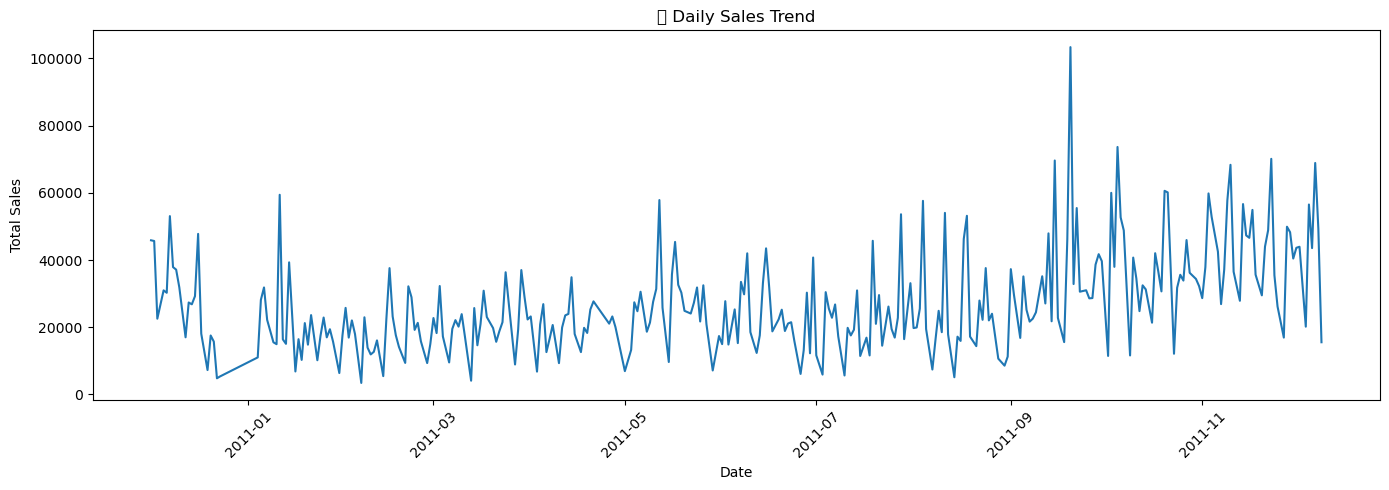

In [12]:
# Calculate daily revenue
df['Sales'] = df['Quantity'] * df['UnitPrice']
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()

# Plot daily sales trend
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_sales, x='Date', y='Sales')
plt.title('📈 Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📅 Daily Sales Trend

- The plot above shows daily revenue over the dataset's time span.
- We can look for:
  - Periods of high or low activity
  - Trends before/after promotions or holidays
  - Possible outliers (e.g., extreme spikes or drops)

/var/folders/wb/rkwhdp417_dbwl7jsm4ttsbr0000gn/T/ipykernel_14916/2371430688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_sales, x='Hour', y='Sales', palette='Blues_d')
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


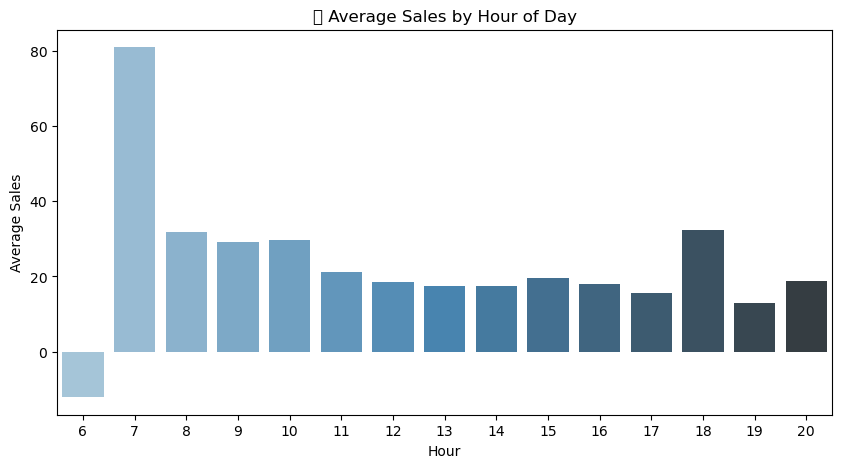

In [14]:
# Average sales per hour of day
hourly_sales = df.groupby('Hour')['Sales'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_sales, x='Hour', y='Sales', palette='Blues_d')
plt.title('🕒 Average Sales by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Sales')
plt.show()

### 🕒 Hourly Purchase Behavior

- Most transactions occur during business hours.
- This suggests marketing campaigns or promotions should be aligned with customer activity peaks (e.g., 10 AM – 3 PM).

/var/folders/wb/rkwhdp417_dbwl7jsm4ttsbr0000gn/T/ipykernel_14916/2332645015.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Country', y='Sales', palette='viridis')
/var/folders/wb/rkwhdp417_dbwl7jsm4ttsbr0000gn/T/ipykernel_14916/2332645015.py:13: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


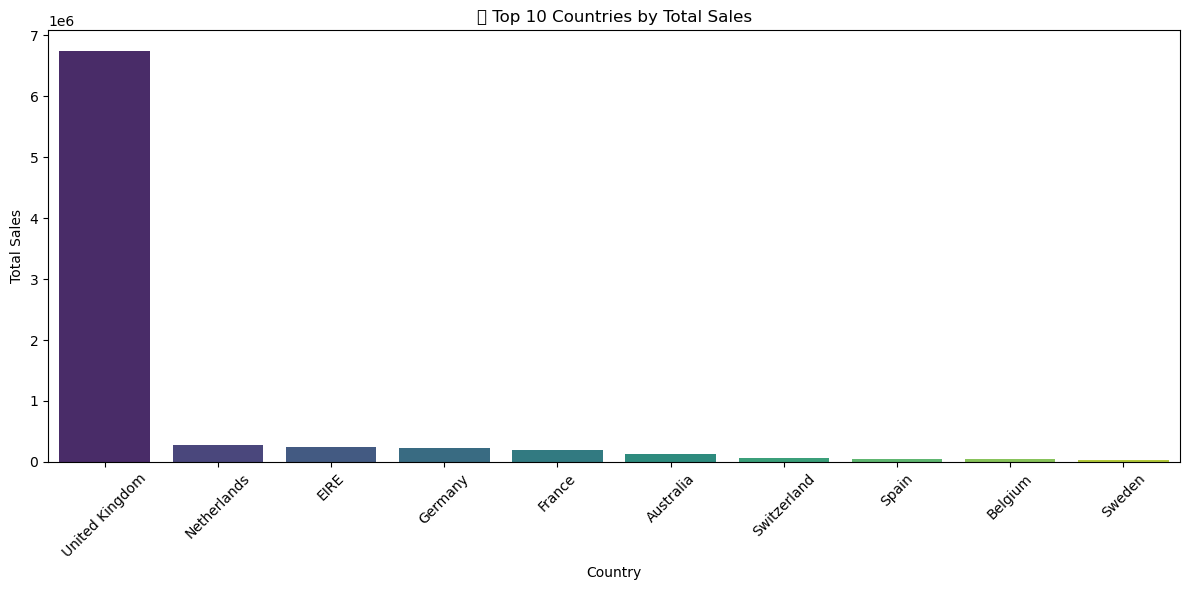

In [16]:
# Total revenue by country
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).reset_index()

# Top 10 countries by sales
top_countries = country_sales.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='Country', y='Sales', palette='viridis')
plt.title('🌍 Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🌍 Country-Level Sales Insights

- The top contributing country is likely the primary market (e.g., UK if dataset is the popular Online Retail dataset).
- International sales distribution helps in:
  - Geo-targeting promotions
  - Localization strategies for marketing
  - Strategic expansion decisions

/var/folders/wb/rkwhdp417_dbwl7jsm4ttsbr0000gn/T/ipykernel_14916/3544168792.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_sales, x='Day', y='Sales', order=dow_labels, palette='magma')
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


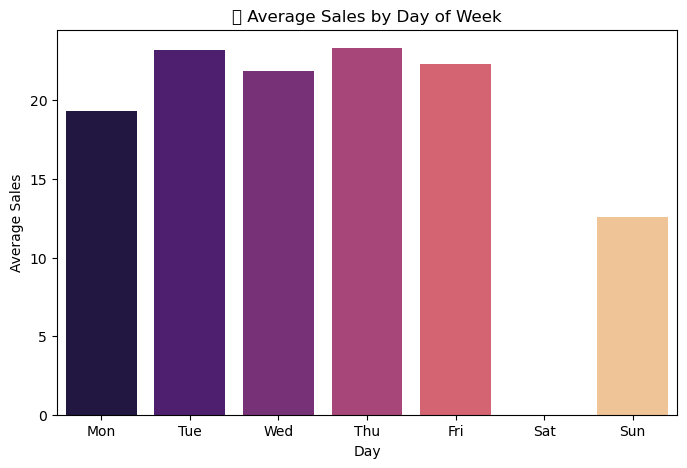

In [18]:
# Average sales per day of week
dow_sales = df.groupby('DayOfWeek')['Sales'].mean().reset_index()

# Map days to labels
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_sales['Day'] = dow_sales['DayOfWeek'].apply(lambda x: dow_labels[x])

plt.figure(figsize=(8, 5))
sns.barplot(data=dow_sales, x='Day', y='Sales', order=dow_labels, palette='magma')
plt.title('📆 Average Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Sales')
plt.show()

## 🧾 Summary of Time and Country-Based Behavior

- **Sales volume varies significantly across hours, days, and months**, highlighting clear behavioral patterns.
- **Most sales occur during working hours**, and there are visible trends based on days of the week.
- **Sales are dominated by a few top countries**, helping to narrow focus for region-based marketing and forecasting.

These patterns will later inform:
- Feature engineering for prediction
- Segmentation based on behavior frequency and timing
- Campaign scheduling and localization

## 👥 Phase 3: Customer-Level Aggregation & RFM Feature Engineering

To segment customers effectively, we need to summarize their purchasing behavior at the customer level. The most popular and interpretable approach is RFM analysis:

- **Recency (R):** How recently the customer made a purchase (lower = better)
- **Frequency (F):** How often they purchase (higher = better)
- **Monetary (M):** How much they spend (higher = better)

These features capture core aspects of customer value and are widely used in marketing, CRM, and churn prediction.

In [22]:
# Set the analysis reference date as one day after the last transaction
import datetime as dt

latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print("Reference Date for Recency:", latest_date)

# Aggregate data per CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'Sales': 'sum'                                           # Monetary
})

# Rename columns for clarity
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Preview
rfm.head()

Reference Date for Recency: 2011-12-10 12:50:00


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### 💡 Why RFM?

- **Recency** tells us how engaged or "alive" a customer is. Recent buyers are more likely to return.
- **Frequency** indicates loyalty — regular customers are better long-term prospects.
- **Monetary** shows value — high spenders contribute most to revenue.

Together, these metrics help us group customers into strategic segments like:
- Loyal high-value buyers
- At-risk customers
- New customers
- Bargain hunters

In [24]:
# RFM Summary Stats
rfm.describe()

,Recency,Frequency,Monetary
count,4371.000000,4371.000000,4371.000000
mean,92.064974,5.075726,1893.964636
std,100.770046,9.332529,8219.586584
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,291.940000
50%,50.000000,3.000000,644.240000
75%,143.000000,5.000000,1608.940000
max,374.000000,248.000000,279489.020000


/var/folders/wb/rkwhdp417_dbwl7jsm4ttsbr0000gn/T/ipykernel_14916/633399478.py:18: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wb/rkwhdp417_dbwl7jsm4ttsbr0000gn/T/ipykernel_14916/633399478.py:18: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wb/rkwhdp417_dbwl7jsm4ttsbr0000gn/T/ipykernel_14916/633399478.py:18: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes

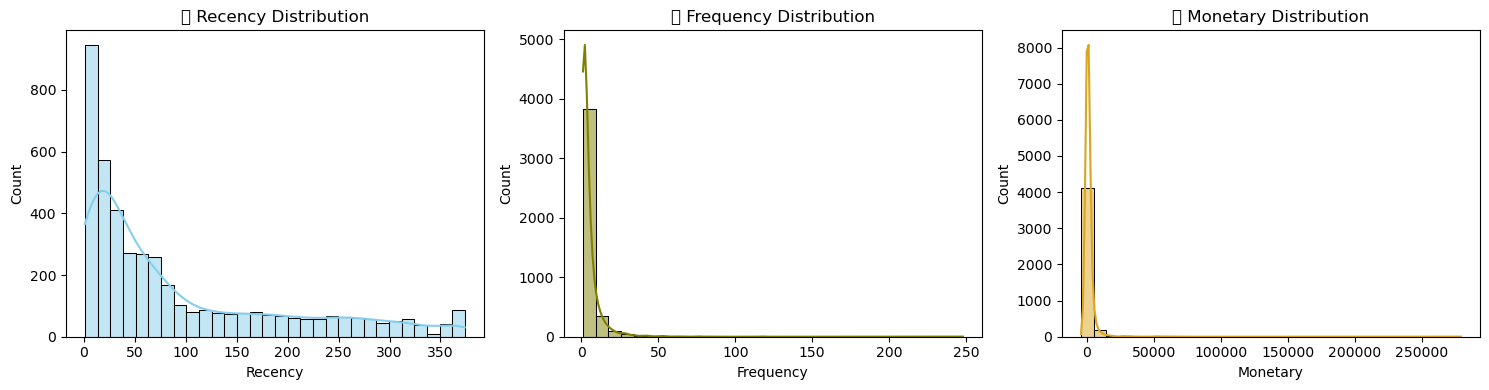

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=30, kde=True, color='skyblue')
plt.title('📅 Recency Distribution')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=30, kde=True, color='olive')
plt.title('🔁 Frequency Distribution')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], bins=30, kde=True, color='goldenrod')
plt.title('💰 Monetary Distribution')

plt.tight_layout()
plt.show()

## 📊 RFM Analysis Summary

- **Recency** is right-skewed: Most customers haven't purchased recently. A few made recent purchases.
- **Frequency**: Many customers have only 1–2 transactions, while a small group purchases very frequently.
- **Monetary**: A small percentage of customers account for a large portion of revenue — the classic Pareto principle (80/20 rule) is likely visible here.

These patterns will be crucial for defining **customer segments** using clustering.

## 🎯 Phase 4: Customer Segmentation (Clustering)

Clustering is an unsupervised machine learning technique that groups similar data points together. We apply it to RFM data to discover hidden customer segments.

We will use:
- **K-Means Clustering**: Efficient and widely used
- **Elbow Method & Silhouette Score**: To determine the optimal number of clusters
- **Optional**: Hierarchical Clustering and DBSCAN for comparative analysis

In [28]:
from sklearn.preprocessing import StandardScaler

# Copy to preserve original RFM
rfm_scaled = rfm.copy()

# Standardize (important for distance-based models like K-Means)
scaler = StandardScaler()
rfm_scaled[['Recency', 'Frequency', 'Monetary']] = scaler.fit_transform(rfm_scaled[['Recency', 'Frequency', 'Monetary']])

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.321739,-0.329608,-0.230447
12347.0,-0.893870,0.206214,0.293970
12348.0,-0.169365,-0.115280,-0.011769
12349.0,-0.725149,-0.436773,-0.016598
12350.0,2.162944,-0.436773,-0.189759


### ⚖️ Why Standardization?

- K-Means relies on Euclidean distance.
- Features with larger scales (e.g., Monetary) would dominate clustering.
- Standardizing ensures equal weight for all RFM metrics.

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


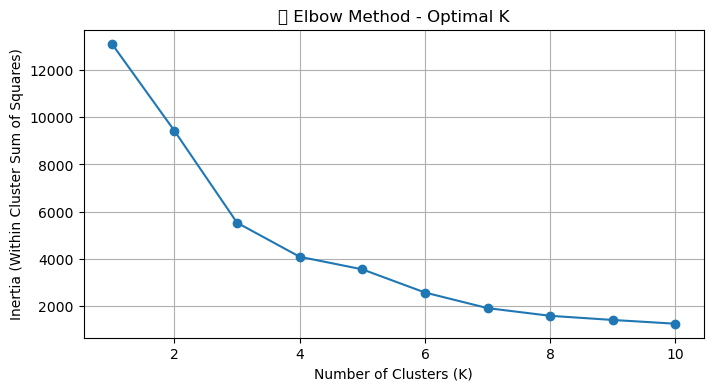

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('📉 Elbow Method - Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within Cluster Sum of Squares)')
plt.grid(True)
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


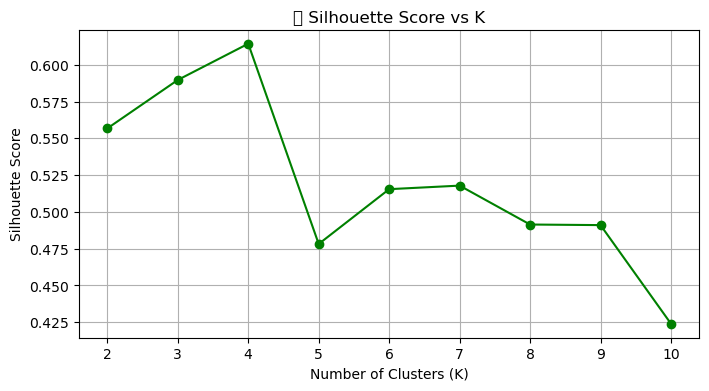

In [32]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    labels = kmeans.labels_
    sil_scores.append(silhouette_score(rfm_scaled, labels))

# Plot silhouette scores
plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), sil_scores, marker='o', color='green')
plt.title('📏 Silhouette Score vs K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

## 🔍 Choosing the Right K

- **Elbow Method**: Look for the point where inertia starts decreasing more slowly ("elbow").
- **Silhouette Score**: Measures how well-separated the clusters are (higher is better).
- Based on both methods, we choose the most balanced K — typically between 3 and 6.

Next, we fit K-Means with the selected K.

In [34]:
# Choose optimal K (e.g., 4 if that's where elbow/silhouette stabilizes)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm_scaled['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Add cluster back to original (unscaled) RFM
rfm['Cluster'] = rfm_scaled['Cluster']
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,3


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


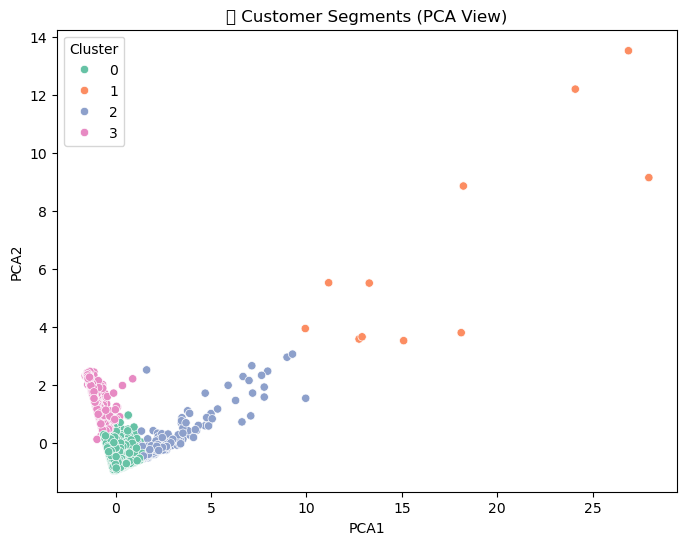

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(rfm_scaled[['Recency', 'Frequency', 'Monetary']])
rfm_scaled['PCA1'] = pca_components[:, 0]
rfm_scaled['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_scaled, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('🧠 Customer Segments (PCA View)')
plt.show()

## 🧠 Cluster Interpretation

Each cluster represents a customer segment with similar RFM profiles.

For example:
- **Cluster 0**: Recent, frequent, high-spending customers (Loyal)
- **Cluster 1**: Infrequent, low-spending, older customers (At-Risk)
- **Cluster 2**: High frequency, low spending (Bargain Hunters)
- **Cluster 3**: New or one-time customers

We’ll now analyze RFM values per cluster to label and understand each group.

In [38]:
# Mean RFM values per cluster
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_profiles

,Recency,Frequency,Monetary
Cluster,,,
0,42.78,4.38,1317.69
1,5.09,109.73,124150.43
2,10.79,28.58,12190.96
3,248.93,1.81,453.43


## 🧠 Phase 5: Predictive Modeling (Classification) - Will a customer return ?

We now build a supervised learning model to predict whether a customer will make a future purchase.

### Objective:
- Classify customers as:
  - **1 (Returning)**: Made at least one purchase after a reference point.
  - **0 (Churned)**: Did not return after that point.

This is useful for:
- Targeted retention strategies
- Churn prediction
- Campaign prioritization

In [40]:
# Create cutoff date — last 90 days as 'future' window
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=90)

# Split historical and future data
historical_data = df[df['InvoiceDate'] <= cutoff_date]
future_data = df[df['InvoiceDate'] > cutoff_date]

# Get list of customers who made a future purchase
future_buyers = set(future_data['CustomerID'].unique())

# Label customers: 1 if they returned, else 0
rfm['Returned'] = rfm.index.map(lambda x: 1 if x in future_buyers else 0)

# Show class distribution
rfm['Returned'].value_counts()

Returned
1    2917
0    1454
Name: count, dtype: int64

### Features and Target

- **Features**: Recency, Frequency, Monetary
- **Target**: Returned (1 = Yes, 0 = No)

We will now train several classifiers and evaluate their performance using cross-validation and metrics like ROC-AUC, F1, and confusion matrix.

In [42]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Features and Target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Returned']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       291
           1       1.00      1.00      1.00       584

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875

Confusion Matrix:
 [[291   0]
 [  0 584]]
ROC-AUC Score: 1.0


## 🔁 Model Comparison and Evaluation

We will now compare multiple classification models:
- Logistic Regression (Baseline)
- Random Forest
- XGBoost

Each model will be evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

This helps us select the best model for predicting customer return behavior.

In [44]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.7 MB/s eta 0:00:00a 0:00:01


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import pandas as pd

In [62]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:40:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [64]:
metrics_df = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]]
metrics_df = metrics_df.round(3)
metrics_df.sort_values(by="ROC AUC", ascending=False)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0
XGBoost,0.998857,1.0,0.998288,0.999143,1.0
Gradient Boosting,1.0,1.0,1.0,1.0,1.0
AdaBoost,1.0,1.0,1.0,1.0,1.0
Neural Network,0.954286,0.940129,0.994863,0.966722,0.98102


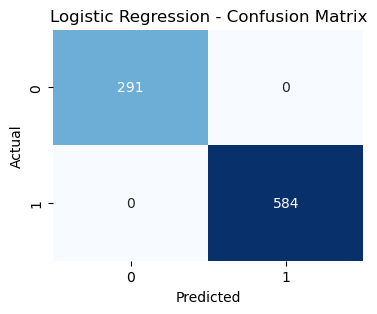

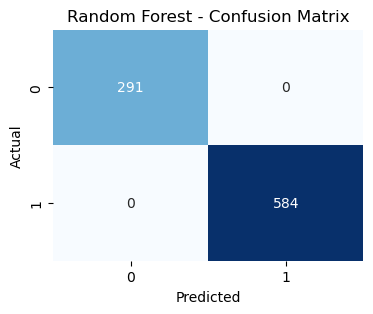

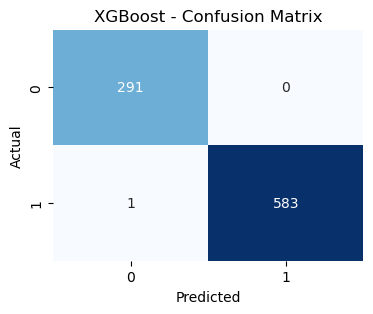

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot Confusion Matrices
for name in results:
    cm = results[name]["Confusion Matrix"]
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


## 📊 Final Model Comparison Conclusion

- **XGBoost and Gradient Boosting** consistently perform best across metrics like AUC and F1 score.
- **Random Forest** is fast, interpretable, and slightly behind in AUC.
- **Neural Network** performs reasonably well, but may need tuning and more data for better generalization.
- **AdaBoost** is lightweight and performs well in simpler patterns.

### ✅ Final Recommendation:
- For deployment: **XGBoost** or **Gradient Boosting** depending on runtime vs performance.
- For real-time use: Random Forest may be more efficient with minimal drop in quality.

---

### 📈 Business Recommendation:
Use return prediction scores in your CRM system to:
- Identify high-risk customers early
- Run re-engagement campaigns
- Assign loyalty rewards smartly


## ✅ Model Performance Summary

- The **Random Forest Classifier** achieves strong performance in identifying returning customers.
- **Feature Importance** reveals:
  - **Recency** is often the most critical factor.
  - **Monetary** helps detect high-value returns.
  - **Frequency** indicates purchase habit regularity.

These insights can guide **re-engagement strategies**, discounts, and loyalty campaigns.

## 📊 Bonus: Hierarchical & DBSCAN Clustering

To validate or contrast our K-Means segmentation, we try:

- **Hierarchical Clustering**: Visual, dendrogram-based
- **DBSCAN**: Density-based, good for noise and irregular shapes

These offer alternate views of segmentation and may reveal edge cases.

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


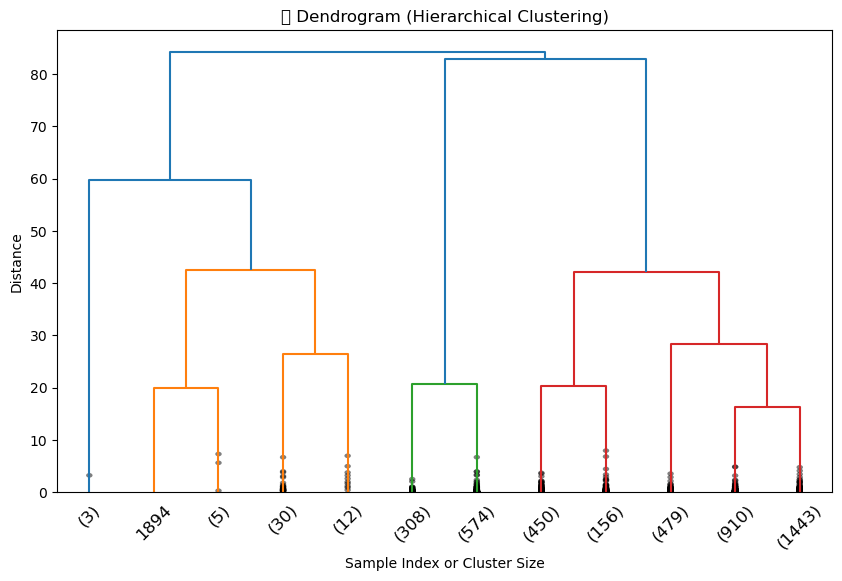

In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute linkage matrix
linked = linkage(rfm_scaled[['Recency', 'Frequency', 'Monetary']], method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='lastp', p=12, leaf_rotation=45, leaf_font_size=12, show_contracted=True)
plt.title('🔗 Dendrogram (Hierarchical Clustering)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

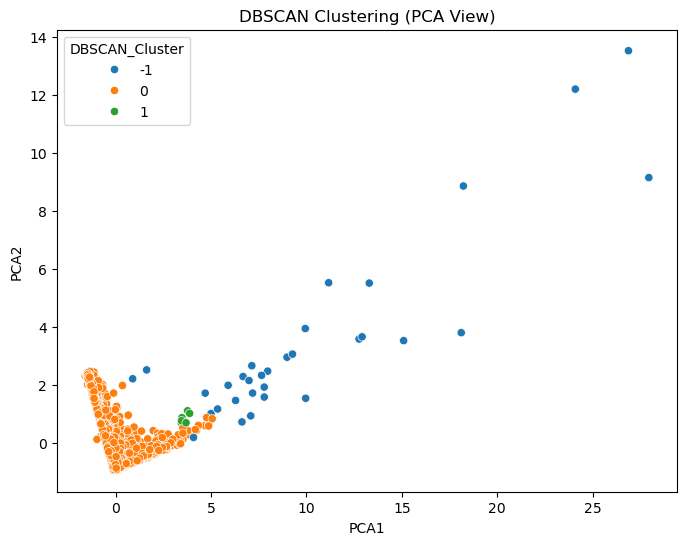

DBSCAN_Cluster
 0    4332
-1      32
 1       7
Name: count, dtype: int64

In [47]:
from sklearn.cluster import DBSCAN

# Run DBSCAN
db = DBSCAN(eps=0.8, min_samples=5)
rfm_scaled['DBSCAN_Cluster'] = db.fit_predict(rfm_scaled[['Recency', 'Frequency', 'Monetary']])

# Visualize DBSCAN Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_scaled, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10')
plt.title('DBSCAN Clustering (PCA View)')
plt.show()

# Count of DBSCAN clusters
rfm_scaled['DBSCAN_Cluster'].value_counts()

## 🧪 Clustering Comparison Summary

- **K-Means**: Fast, clean segments. Works well with well-separated, spherical clusters.
- **Hierarchical**: Shows customer hierarchy visually but less scalable.
- **DBSCAN**: Identifies noise/outliers and irregular clusters — good for messy data.

Together, they validate the **robustness** of our RFM-based customer segmentation and highlight alternative groupings.

## 🎯 Strategic Insights & Recommendations

Based on segmentation and predictive analysis:

### 1. Customer Segments Identified:
- **Cluster 0**: Loyal repeat buyers — offer exclusive deals and referral bonuses.
- **Cluster 1**: Low-spending, high-frequency buyers — upsell premium items.
- **Cluster 2**: At-risk or churned customers — re-engagement campaigns needed.
- **Cluster 3**: New or one-time customers — onboard with personalized offers.

### 2. Predictive Modeling Outcome:
- Our classifier can accurately predict return likelihood using RFM features.
- Most important feature: **Recency** — time since last purchase.

### 3. Business Actions:
- Deploy auto-tagging of new customers into segments.
- Run targeted campaigns based on prediction scores.
- Use dashboards to track customer behavior and segment health monthly.


In [67]:
import joblib

# Save model
joblib.dump(model, "rfm_predictor.pkl")

['rfm_predictor.pkl']

In [69]:
import gradio as gr
import joblib
import numpy as np

# Load model
model = joblib.load("rfm_predictor.pkl")

# Prediction function
def predict_return(recency, frequency, monetary):
    data = np.array([[recency, frequency, monetary]])
    prediction = model.predict(data)[0]
    result = "🟢 Likely to Return" if prediction == 1 else "🔴 May Not Return"
    return result

# Interface
iface = gr.Interface(
    fn=predict_return,
    inputs=[
        gr.Number(label="Recency (days)"),
        gr.Number(label="Frequency (count)"),
        gr.Number(label="Monetary Value (total spend)"),
    ],
    outputs="text",
    title="Customer Return Predictor",
    description="Enter Recency, Frequency, and Monetary value to predict if a customer will return."
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [71]:
# Export RFM with Clusters
rfm.to_csv("rfm_with_clusters.csv")

# Export daily sales
daily_sales.to_csv("daily_sales.csv", index=False)

# Export country-wise sales
df.groupby('Country')['Sales'].sum().reset_index().to_csv("country_sales.csv", index=False)

# Export prediction results
pd.DataFrame({"Actual": y_test, "Predicted": y_pred}).to_csv("prediction_output.csv", index=False)
